    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

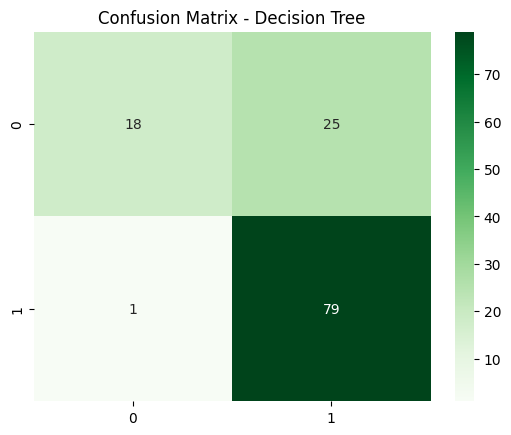

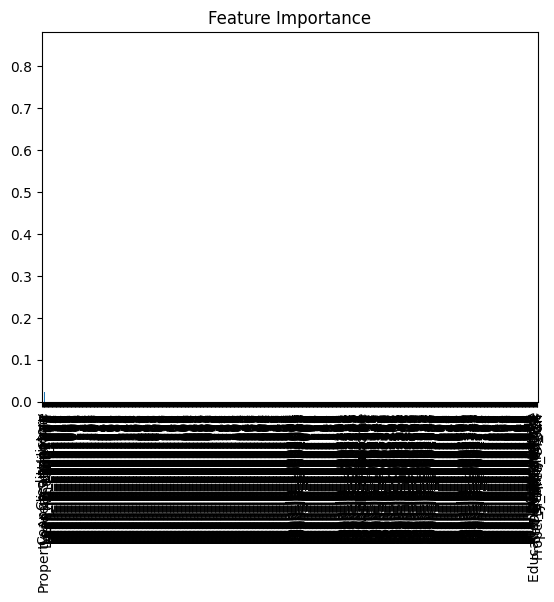

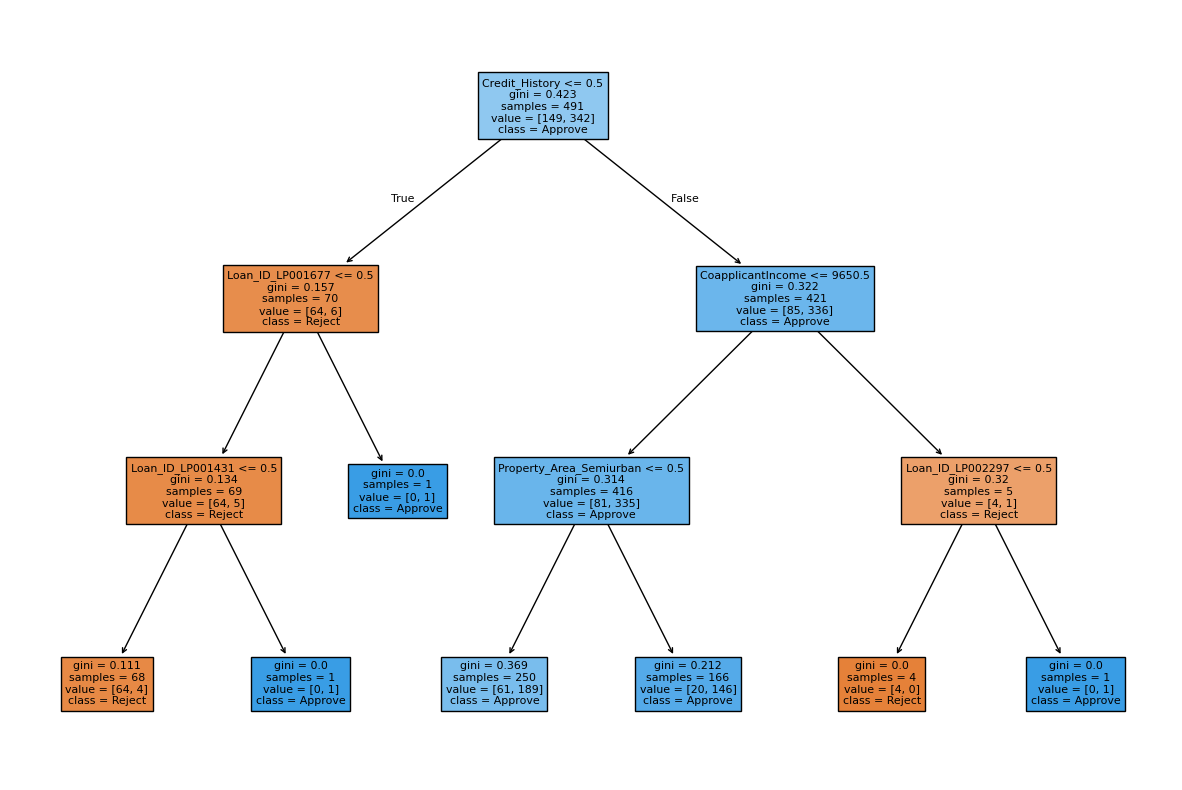

Train Accuracy (Deep): 1.0
Test Accuracy (Deep): 0.7235772357723578


In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

loan = pd.read_csv(r"C:\Users\User\Downloads\ML\EXP-5\archive (9)\train_u6lujuX_CVtuZ9i (1).csv")

print(loan.head())
print(loan.info())

loan.fillna(loan.mode().iloc[0], inplace=True)

loan = pd.get_dummies(loan, drop_first=True)

X = loan.drop("Loan_Status_Y", axis=1)
y = loan["Loan_Status_Y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=['Reject','Approve'],
          filled=True)
plt.show()

dt_deep = DecisionTreeClassifier(random_state=42)
dt_deep.fit(X_train, y_train)

print("Train Accuracy (Deep):", dt_deep.score(X_train, y_train))
print("Test Accuracy (Deep):", dt_deep.score(X_test, y_test))